     CHAOTIC AUDIO ENCRYPTION SYSTEM

Encryption Method:
Lorenz X, Y, Z
       ↓
Q8.8 16-bit conversion
       ↓
X16 XOR Y16 XOR Z16
       ↓
16-bit chaotic key stream
       ↓
Audio sample XOR key

Upload ONE 16-bit PCM WAV audio file:


Saving sample-6s.wav to sample-6s (1).wav

Uploaded file: sample-6s (1).wav

          AUDIO INFORMATION
File: sample-6s (1).wav
Channels: 2
Bit depth: 16 bits
Sample rate: 44100 Hz
Number of frames: 281856
Compression: NONE
Compression name: not compressed

✓ WAV format confirmed
✓ Uncompressed PCM confirmed
✓ 16-bit depth confirmed
✓ Stereo audio confirmed
✓ Audio validation successful

             AUDIO LOADED
Total 16-bit samples: 563712
Audio channels: 2
Sample rate: 44100 Hz

Generating Lorenz chaotic sequence...
✓ Lorenz sequence generated
✓ Warm-up steps: 1000

Generating combined chaotic key...
✓ X converted to 16-bit Q8.8
✓ Y converted to 16-bit Q8.8
✓ Z converted to 16-bit Q8.8
✓ X XOR Y XOR Z completed
✓ Final 16-bit chaotic key stream generated

        LORENZ KEY GENERATION

Step 0
X = 8.60669366
Y = 5.78879441
Z = 30.44236724
X16 = 2203
Y16 = 1482
Z16 = 7793
Final Key = 4896

Step 1
X = 8.32490373
Y = 5.52069939
Z = 30.12879459
X16 = 2131
Y16 = 1413
Z16 = 7713
Final Key

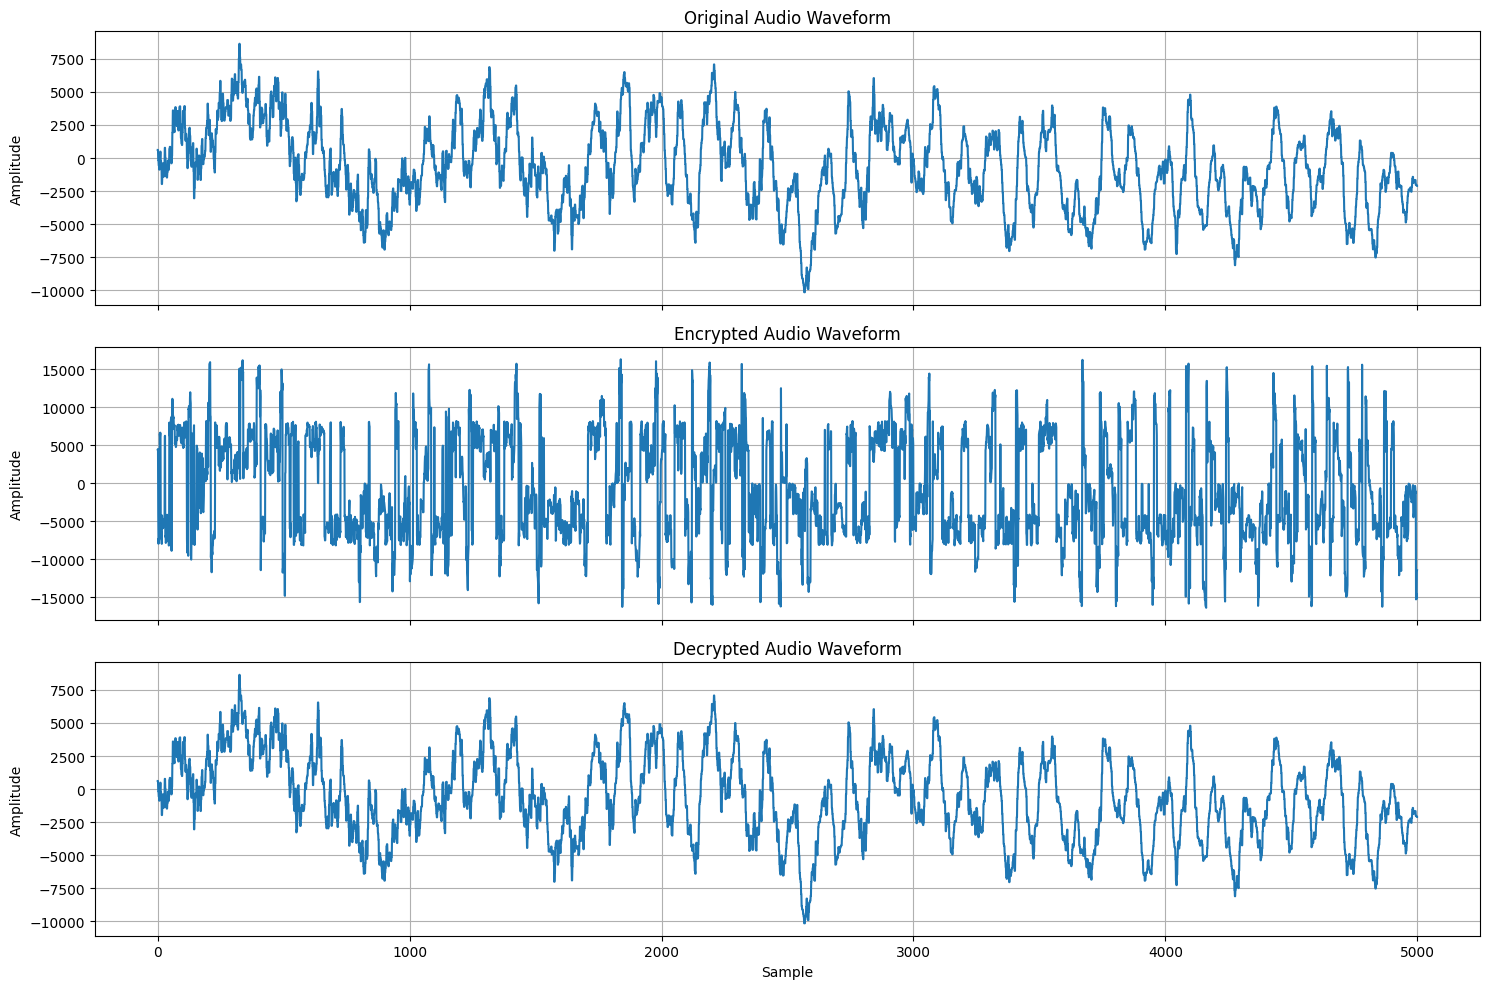


             AUDIO PLAYBACK

Original Audio:



Encrypted Audio:



Decrypted Audio:



Preparing files for download...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


       ✓ COMPLETE PROCESS FINISHED

Output files:
1. encrypted_audio.wav
2. decrypted_audio.wav
3. audio_test_vectors.csv
4. lorenz_key_stream.csv
5. waveform_comparison.png


In [2]:
import numpy as np
import wave
import hashlib
import csv
import matplotlib.pyplot as plt

from IPython.display import Audio, display
from google.colab import files


# ============================================================
# CHAOTIC AUDIO ENCRYPTION SYSTEM
# ============================================================
#
# METHOD:
#
# 16-bit PCM WAV
#       ↓
# Audio Samples
#       ↓
# Lorenz Attractor
#       ↓
# X, Y, Z
#       ↓
# Q8.8 Fixed-Point Conversion
#       ↓
# X16 XOR Y16 XOR Z16
#       ↓
# 16-bit Chaotic Key Stream
#       ↓
# Audio Sample XOR Key
#       ↓
# Encrypted Audio
#
# DECRYPTION:
#
# Encrypted Sample XOR Same Key
#       ↓
# Original Sample
#
# ============================================================


# ============================================================
# CONFIGURATION
# ============================================================

SIGMA = 10.0
RHO = 28.0
BETA = 8.0 / 3.0

X0 = 1.0
Y0 = 1.0
Z0 = 1.0

DT = 0.01

# Number of initial Lorenz iterations discarded
WARMUP_STEPS = 1000

# Q8.8 fixed-point scaling
#
# 8 fractional bits:
#
# 2^8 = 256
#
FIXED_POINT_SCALE = 256

# Number of Lorenz steps displayed
LORENZ_DISPLAY_STEPS = 5

# Number of test vectors displayed
TEST_VECTOR_DISPLAY = 5

# Number of samples displayed in waveform
WAVEFORM_SAMPLES = 5000


# ============================================================
# LORENZ ATTRACTOR
# ============================================================

def lorenz_step(x, y, z):

    # Lorenz differential equations

    dx = SIGMA * (y - x)

    dy = x * (RHO - z) - y

    dz = x * y - BETA * z

    # Euler numerical integration

    x_new = x + dx * DT

    y_new = y + dy * DT

    z_new = z + dz * DT

    return x_new, y_new, z_new


# ============================================================
# GENERATE LORENZ SEQUENCE
# ============================================================

def generate_lorenz_sequence(num_samples):

    # Initial conditions

    x = X0
    y = Y0
    z = Z0

    # --------------------------------------------------------
    # WARM-UP
    # --------------------------------------------------------
    #
    # Initial transient values are discarded so that the
    # generated sequence starts after the warm-up period.
    # --------------------------------------------------------

    for _ in range(WARMUP_STEPS):

        x, y, z = lorenz_step(
            x,
            y,
            z
        )

    # --------------------------------------------------------
    # Allocate arrays
    # --------------------------------------------------------

    x_values = np.zeros(
        num_samples,
        dtype=np.float64
    )

    y_values = np.zeros(
        num_samples,
        dtype=np.float64
    )

    z_values = np.zeros(
        num_samples,
        dtype=np.float64
    )

    # --------------------------------------------------------
    # Generate chaotic sequence
    # --------------------------------------------------------

    for i in range(num_samples):

        x, y, z = lorenz_step(
            x,
            y,
            z
        )

        x_values[i] = x

        y_values[i] = y

        z_values[i] = z

    return (
        x_values,
        y_values,
        z_values
    )


# ============================================================
# Q8.8 FIXED-POINT CONVERSION
# ============================================================

def lorenz_to_16bit(values):

    # --------------------------------------------------------
    # Q8.8 REPRESENTATION
    #
    # 16 total bits:
    #
    # 8 bits  = integer portion
    # 8 bits  = fractional portion
    #
    # Therefore:
    #
    # value × 2^8
    # = value × 256
    #
    # --------------------------------------------------------

    scaled = np.round(
        values * FIXED_POINT_SCALE
    )

    # Convert to signed integer first

    scaled_int32 = scaled.astype(
        np.int32
    )

    # Store the 16-bit binary representation

    values_16 = scaled_int32.astype(
        np.uint16
    )

    return values_16


# ============================================================
# GENERATE COMBINED CHAOTIC KEY
# ============================================================

def generate_chaotic_key(
    x_values,
    y_values,
    z_values
):

    # --------------------------------------------------------
    # Convert Lorenz X, Y and Z to 16-bit values
    # --------------------------------------------------------

    x_key = lorenz_to_16bit(
        x_values
    )

    y_key = lorenz_to_16bit(
        y_values
    )

    z_key = lorenz_to_16bit(
        z_values
    )

    # --------------------------------------------------------
    # Combine X and Y
    # --------------------------------------------------------

    xy_key = np.bitwise_xor(
        x_key,
        y_key
    )

    # --------------------------------------------------------
    # Combine X XOR Y with Z
    # --------------------------------------------------------

    chaotic_key = np.bitwise_xor(
        xy_key,
        z_key
    )

    return (
        x_key,
        y_key,
        z_key,
        chaotic_key
    )


# ============================================================
# AUDIO VALIDATION
# ============================================================

def validate_audio(filename):

    # --------------------------------------------------------
    # Check WAV extension
    # --------------------------------------------------------

    if not filename.lower().endswith(".wav"):

        raise ValueError(
            "Invalid file format.\n"
            "Please upload a WAV audio file."
        )

    # --------------------------------------------------------
    # Read WAV information
    # --------------------------------------------------------

    try:

        with wave.open(
            filename,
            "rb"
        ) as audio:

            channels = audio.getnchannels()

            sample_width = audio.getsampwidth()

            sample_rate = audio.getframerate()

            num_frames = audio.getnframes()

            compression = audio.getcomptype()

            compression_name = audio.getcompname()

    except wave.Error as error:

        raise ValueError(
            f"Unable to read WAV file: {error}"
        )

    # --------------------------------------------------------
    # Display information
    # --------------------------------------------------------

    print("\n========================================")
    print("          AUDIO INFORMATION")
    print("========================================")

    print(
        "File:",
        filename
    )

    print(
        "Channels:",
        channels
    )

    print(
        "Bit depth:",
        sample_width * 8,
        "bits"
    )

    print(
        "Sample rate:",
        sample_rate,
        "Hz"
    )

    print(
        "Number of frames:",
        num_frames
    )

    print(
        "Compression:",
        compression
    )

    print(
        "Compression name:",
        compression_name
    )

    # --------------------------------------------------------
    # Check mono/stereo
    # --------------------------------------------------------

    if channels not in [1, 2]:

        raise ValueError(
            f"Unsupported number of channels: {channels}.\n"
            "Only mono and stereo WAV files are supported."
        )

    # --------------------------------------------------------
    # Check PCM
    # --------------------------------------------------------

    if compression != "NONE":

        raise ValueError(
            "Unsupported audio encoding.\n"
            "Please upload an uncompressed PCM WAV file."
        )

    # --------------------------------------------------------
    # Check 16-bit
    # --------------------------------------------------------

    if sample_width != 2:

        raise ValueError(
            f"Unsupported bit depth: "
            f"{sample_width * 8}-bit.\n\n"
            "This implementation requires "
            "16-bit PCM WAV audio."
        )

    # --------------------------------------------------------
    # Confirmation
    # --------------------------------------------------------

    print("\n✓ WAV format confirmed")

    print("✓ Uncompressed PCM confirmed")

    print("✓ 16-bit depth confirmed")

    if channels == 1:

        print("✓ Mono audio confirmed")

    else:

        print("✓ Stereo audio confirmed")

    print("✓ Audio validation successful")

    return (
        channels,
        sample_rate,
        num_frames
    )


# ============================================================
# READ AUDIO
# ============================================================

def read_audio(filename):

    with wave.open(
        filename,
        "rb"
    ) as audio:

        channels = audio.getnchannels()

        sample_rate = audio.getframerate()

        frames = audio.readframes(
            audio.getnframes()
        )

    # --------------------------------------------------------
    # Convert raw PCM bytes to signed 16-bit samples
    # --------------------------------------------------------

    samples = np.frombuffer(
        frames,
        dtype=np.int16
    ).copy()

    return (
        samples,
        channels,
        sample_rate
    )


# ============================================================
# WRITE AUDIO
# ============================================================

def write_audio(
    filename,
    samples,
    channels,
    sample_rate
):

    with wave.open(
        filename,
        "wb"
    ) as audio:

        audio.setnchannels(
            channels
        )

        # 16-bit PCM = 2 bytes

        audio.setsampwidth(
            2
        )

        audio.setframerate(
            sample_rate
        )

        audio.writeframes(
            samples.astype(
                np.int16
            ).tobytes()
        )


# ============================================================
# ENCRYPT AUDIO
# ============================================================

def encrypt_audio(
    samples,
    chaotic_key
):

    # --------------------------------------------------------
    # Convert signed int16 to uint16.
    #
    # This preserves the exact 16-bit binary representation.
    # --------------------------------------------------------

    samples_uint = samples.view(
        np.uint16
    )

    # --------------------------------------------------------
    # XOR every audio sample with one chaotic key.
    # --------------------------------------------------------

    encrypted_uint = np.bitwise_xor(
        samples_uint,
        chaotic_key
    )

    # --------------------------------------------------------
    # Convert back to signed int16.
    # --------------------------------------------------------

    encrypted_samples = encrypted_uint.view(
        np.int16
    )

    return encrypted_samples


# ============================================================
# DECRYPT AUDIO
# ============================================================

def decrypt_audio(
    encrypted_samples,
    chaotic_key
):

    # Convert encrypted samples to uint16

    encrypted_uint = encrypted_samples.view(
        np.uint16
    )

    # --------------------------------------------------------
    # XOR with the SAME key.
    #
    # XOR property:
    #
    # A XOR B XOR B = A
    #
    # --------------------------------------------------------

    decrypted_uint = np.bitwise_xor(
        encrypted_uint,
        chaotic_key
    )

    # Convert back to signed int16

    decrypted_samples = decrypted_uint.view(
        np.int16
    )

    return decrypted_samples


# ============================================================
# SHA-256 HASH
# ============================================================

def calculate_hash(samples):

    return hashlib.sha256(
        samples.tobytes()
    ).hexdigest()


# ============================================================
# CORRELATION
# ============================================================

def calculate_correlation(
    original,
    encrypted
):

    return np.corrcoef(
        original.astype(np.float64),
        encrypted.astype(np.float64)
    )[0, 1]


# ============================================================
# KEY STREAM STATISTICS
# ============================================================

def analyze_key_stream(chaotic_key):

    unique_keys = len(
        np.unique(chaotic_key)
    )

    total_keys = len(
        chaotic_key
    )

    zero_keys = np.sum(
        chaotic_key == 0
    )

    repeated_keys = (
        total_keys - unique_keys
    )

    print("\n========================================")
    print("          KEY STREAM ANALYSIS")
    print("========================================")

    print(
        "Total keys:",
        total_keys
    )

    print(
        "Unique keys:",
        unique_keys
    )

    print(
        "Minimum key:",
        np.min(chaotic_key)
    )

    print(
        "Maximum key:",
        np.max(chaotic_key)
    )

    print(
        "Zero keys:",
        zero_keys
    )

    print(
        "Repeated keys:",
        repeated_keys
    )


# ============================================================
# SAMPLE CHANGE ANALYSIS
# ============================================================

def analyze_encryption_changes(
    original_samples,
    encrypted_samples
):

    unchanged = np.sum(
        original_samples == encrypted_samples
    )

    total = len(
        original_samples
    )

    changed = total - unchanged

    percentage_changed = (
        changed / total
    ) * 100

    print("\n========================================")
    print("       ENCRYPTION CHANGE ANALYSIS")
    print("========================================")

    print(
        "Total samples:",
        total
    )

    print(
        "Changed samples:",
        changed
    )

    print(
        "Unchanged samples:",
        unchanged
    )

    print(
        "Percentage changed:",
        f"{percentage_changed:.6f}%"
    )

    return percentage_changed


# ============================================================
# DISPLAY LORENZ KEY GENERATION
# ============================================================

def display_lorenz_steps(
    x_values,
    y_values,
    z_values,
    x_key,
    y_key,
    z_key,
    chaotic_key
):

    print("\n========================================")
    print("        LORENZ KEY GENERATION")
    print("========================================")

    number_of_steps = min(
        LORENZ_DISPLAY_STEPS,
        len(x_values)
    )

    for i in range(
        number_of_steps
    ):

        print(
            f"\nStep {i}"
        )

        print(
            f"X = {x_values[i]:.8f}"
        )

        print(
            f"Y = {y_values[i]:.8f}"
        )

        print(
            f"Z = {z_values[i]:.8f}"
        )

        print(
            f"X16 = {int(x_key[i])}"
        )

        print(
            f"Y16 = {int(y_key[i])}"
        )

        print(
            f"Z16 = {int(z_key[i])}"
        )

        print(
            f"Final Key = {int(chaotic_key[i])}"
        )


# ============================================================
# DISPLAY TEST VECTORS
# ============================================================

def display_test_values(
    original_samples,
    x_key,
    y_key,
    z_key,
    chaotic_key,
    encrypted_samples,
    decrypted_samples
):

    print("\n========================================")
    print("          FIRST TEST VECTORS")
    print("========================================")

    number_of_values = min(
        TEST_VECTOR_DISPLAY,
        len(original_samples)
    )

    for i in range(
        number_of_values
    ):

        print(
            f"\nSample {i}"
        )

        print(
            f"Original   = {original_samples[i]}"
        )

        print(
            f"X16        = {int(x_key[i])}"
        )

        print(
            f"Y16        = {int(y_key[i])}"
        )

        print(
            f"Z16        = {int(z_key[i])}"
        )

        print(
            f"Final Key  = {int(chaotic_key[i])}"
        )

        print(
            f"Encrypted  = {encrypted_samples[i]}"
        )

        print(
            f"Decrypted  = {decrypted_samples[i]}"
        )


# ============================================================
# SAVE COMPLETE AUDIO TEST VECTORS
# ============================================================

def save_test_vectors(
    filename,
    original_samples,
    x_values,
    y_values,
    z_values,
    x_key,
    y_key,
    z_key,
    chaotic_key,
    encrypted_samples,
    decrypted_samples
):

    headers = [
        "Sample_Index",
        "X",
        "Y",
        "Z",
        "X16_Q8.8",
        "Y16_Q8.8",
        "Z16_Q8.8",
        "Final_Key",
        "Original_Sample",
        "Encrypted_Sample",
        "Decrypted_Sample"
    ]

    with open(
        filename,
        "w",
        newline=""
    ) as csvfile:

        writer = csv.writer(
            csvfile
        )

        writer.writerow(
            headers
        )

        # ----------------------------------------------------
        # Save every sample
        # ----------------------------------------------------

        for i in range(
            len(original_samples)
        ):

            writer.writerow(
                [
                    i,

                    f"{x_values[i]:.10f}",

                    f"{y_values[i]:.10f}",

                    f"{z_values[i]:.10f}",

                    int(x_key[i]),

                    int(y_key[i]),

                    int(z_key[i]),

                    int(chaotic_key[i]),

                    int(original_samples[i]),

                    int(encrypted_samples[i]),

                    int(decrypted_samples[i])
                ]
            )

    print(
        "\n✓ Complete audio test vectors saved:",
        filename
    )


# ============================================================
# SAVE COMPLETE LORENZ KEY STREAM
# ============================================================

def save_key_stream(
    filename,
    x_values,
    y_values,
    z_values,
    x_key,
    y_key,
    z_key,
    chaotic_key
):

    headers = [
        "Index",
        "X",
        "Y",
        "Z",
        "X16_Q8.8",
        "Y16_Q8.8",
        "Z16_Q8.8",
        "Final_Key"
    ]

    with open(
        filename,
        "w",
        newline=""
    ) as csvfile:

        writer = csv.writer(
            csvfile
        )

        writer.writerow(
            headers
        )

        # ----------------------------------------------------
        # Save entire key stream
        # ----------------------------------------------------

        for i in range(
            len(chaotic_key)
        ):

            writer.writerow(
                [
                    i,

                    f"{x_values[i]:.10f}",

                    f"{y_values[i]:.10f}",

                    f"{z_values[i]:.10f}",

                    int(x_key[i]),

                    int(y_key[i]),

                    int(z_key[i]),

                    int(chaotic_key[i])
                ]
            )

    print(
        "✓ Complete Lorenz key stream saved:",
        filename
    )


# ============================================================
# WAVEFORM COMPARISON
# ============================================================

def plot_waveform_comparison(
    original_samples,
    encrypted_samples,
    decrypted_samples
):

    display_samples = min(
        WAVEFORM_SAMPLES,
        len(original_samples)
    )

    x = np.arange(
        display_samples
    )

    # --------------------------------------------------------
    # Create three waveform plots
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(15, 10),
        sharex=True
    )

    # --------------------------------------------------------
    # Original waveform
    # --------------------------------------------------------

    axes[0].plot(
        x,
        original_samples[
            :display_samples
        ]
    )

    axes[0].set_title(
        "Original Audio Waveform"
    )

    axes[0].set_ylabel(
        "Amplitude"
    )

    axes[0].grid(
        True
    )

    # --------------------------------------------------------
    # Encrypted waveform
    # --------------------------------------------------------

    axes[1].plot(
        x,
        encrypted_samples[
            :display_samples
        ]
    )

    axes[1].set_title(
        "Encrypted Audio Waveform"
    )

    axes[1].set_ylabel(
        "Amplitude"
    )

    axes[1].grid(
        True
    )

    # --------------------------------------------------------
    # Decrypted waveform
    # --------------------------------------------------------

    axes[2].plot(
        x,
        decrypted_samples[
            :display_samples
        ]
    )

    axes[2].set_title(
        "Decrypted Audio Waveform"
    )

    axes[2].set_xlabel(
        "Sample"
    )

    axes[2].set_ylabel(
        "Amplitude"
    )

    axes[2].grid(
        True
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Save waveform image
    # --------------------------------------------------------

    filename = (
        "waveform_comparison.png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    print(
        "\n✓ Waveform comparison saved:",
        filename
    )

    plt.show()


# ============================================================
# START PROGRAM
# ============================================================

print("========================================")
print("     CHAOTIC AUDIO ENCRYPTION SYSTEM")
print("========================================")

print(
    "\nEncryption Method:"
)

print(
    "Lorenz X, Y, Z"
)

print(
    "       ↓"
)

print(
    "Q8.8 16-bit conversion"
)

print(
    "       ↓"
)

print(
    "X16 XOR Y16 XOR Z16"
)

print(
    "       ↓"
)

print(
    "16-bit chaotic key stream"
)

print(
    "       ↓"
)

print(
    "Audio sample XOR key"
)


print(
    "\nUpload ONE 16-bit PCM WAV audio file:"
)


# ============================================================
# UPLOAD
# ============================================================

uploaded = files.upload()


# ============================================================
# CHECK UPLOAD
# ============================================================

if len(uploaded) == 0:

    raise ValueError(
        "No file was uploaded."
    )


if len(uploaded) > 1:

    raise ValueError(
        "Please upload only ONE WAV file."
    )


filename = list(
    uploaded.keys()
)[0]


print(
    "\nUploaded file:",
    filename
)


# ============================================================
# VALIDATE AUDIO
# ============================================================

channels, sample_rate, num_frames = (
    validate_audio(
        filename
    )
)


# ============================================================
# READ AUDIO
# ============================================================

original_samples, channels, sample_rate = (
    read_audio(
        filename
    )
)


print("\n========================================")
print("             AUDIO LOADED")
print("========================================")

print(
    "Total 16-bit samples:",
    len(original_samples)
)

print(
    "Audio channels:",
    channels
)

print(
    "Sample rate:",
    sample_rate,
    "Hz"
)


# ============================================================
# GENERATE LORENZ SEQUENCE
# ============================================================

print(
    "\nGenerating Lorenz chaotic sequence..."
)


x_values, y_values, z_values = (
    generate_lorenz_sequence(
        len(original_samples)
    )
)


print(
    "✓ Lorenz sequence generated"
)

print(
    "✓ Warm-up steps:",
    WARMUP_STEPS
)


# ============================================================
# GENERATE CHAOTIC KEY
# ============================================================

print(
    "\nGenerating combined chaotic key..."
)


x_key, y_key, z_key, chaotic_key = (
    generate_chaotic_key(
        x_values,
        y_values,
        z_values
    )
)


print(
    "✓ X converted to 16-bit Q8.8"
)

print(
    "✓ Y converted to 16-bit Q8.8"
)

print(
    "✓ Z converted to 16-bit Q8.8"
)

print(
    "✓ X XOR Y XOR Z completed"
)

print(
    "✓ Final 16-bit chaotic key stream generated"
)


# ============================================================
# DISPLAY LORENZ KEY GENERATION
# ============================================================

display_lorenz_steps(
    x_values,
    y_values,
    z_values,
    x_key,
    y_key,
    z_key,
    chaotic_key
)


# ============================================================
# KEY STREAM ANALYSIS
# ============================================================

analyze_key_stream(
    chaotic_key
)


# ============================================================
# ENCRYPT AUDIO
# ============================================================

print(
    "\nEncrypting audio..."
)


encrypted_samples = encrypt_audio(
    original_samples,
    chaotic_key
)


print(
    "✓ Every 16-bit PCM sample encrypted"
)


# ============================================================
# ENCRYPTION CHANGE ANALYSIS
# ============================================================

percentage_changed = (
    analyze_encryption_changes(
        original_samples,
        encrypted_samples
    )
)


# ============================================================
# SAVE ENCRYPTED AUDIO
# ============================================================

encrypted_filename = (
    "encrypted_audio.wav"
)


write_audio(
    encrypted_filename,
    encrypted_samples,
    channels,
    sample_rate
)


print(
    "\n✓ Encrypted file saved:",
    encrypted_filename
)


# ============================================================
# DECRYPT AUDIO
# ============================================================

print(
    "\nDecrypting audio..."
)


decrypted_samples = decrypt_audio(
    encrypted_samples,
    chaotic_key
)


print(
    "✓ Decryption completed"
)


# ============================================================
# SAVE DECRYPTED AUDIO
# ============================================================

decrypted_filename = (
    "decrypted_audio.wav"
)


write_audio(
    decrypted_filename,
    decrypted_samples,
    channels,
    sample_rate
)


print(
    "✓ Decrypted file saved:",
    decrypted_filename
)


# ============================================================
# DISPLAY TEST VECTORS
# ============================================================

display_test_values(
    original_samples,
    x_key,
    y_key,
    z_key,
    chaotic_key,
    encrypted_samples,
    decrypted_samples
)


# ============================================================
# SAVE COMPLETE AUDIO TEST VECTORS
# ============================================================

test_vector_filename = (
    "audio_test_vectors.csv"
)


save_test_vectors(
    test_vector_filename,
    original_samples,
    x_values,
    y_values,
    z_values,
    x_key,
    y_key,
    z_key,
    chaotic_key,
    encrypted_samples,
    decrypted_samples
)


# ============================================================
# SAVE COMPLETE LORENZ KEY STREAM
# ============================================================

key_stream_filename = (
    "lorenz_key_stream.csv"
)


save_key_stream(
    key_stream_filename,
    x_values,
    y_values,
    z_values,
    x_key,
    y_key,
    z_key,
    chaotic_key
)


# ============================================================
# SHA-256 VERIFICATION
# ============================================================

original_hash = calculate_hash(
    original_samples
)

decrypted_hash = calculate_hash(
    decrypted_samples
)


# ============================================================
# SAMPLE-BY-SAMPLE VERIFICATION
# ============================================================

samples_match = np.array_equal(
    original_samples,
    decrypted_samples
)


# ============================================================
# HASH VERIFICATION
# ============================================================

hash_match = (
    original_hash == decrypted_hash
)


# ============================================================
# CORRELATION
# ============================================================

correlation = calculate_correlation(
    original_samples,
    encrypted_samples
)


# ============================================================
# FINAL RESULTS
# ============================================================

print("\n========================================")
print("             FINAL RESULTS")
print("========================================")

print(
    "\nOriginal SHA-256:"
)

print(
    original_hash
)

print(
    "\nDecrypted SHA-256:"
)

print(
    decrypted_hash
)

print(
    "\nSample-by-sample match:",
    samples_match
)

print(
    "SHA-256 match:",
    hash_match
)

print(
    "Original/Encrypted correlation:",
    correlation
)

print(
    "Percentage of samples changed:",
    f"{percentage_changed:.6f}%"
)


# ============================================================
# SUCCESS / ERROR
# ============================================================

if samples_match and hash_match:

    print("\n========================================")
    print("              ✓ SUCCESS")
    print("========================================")

    print(
        "Decrypted audio is EXACTLY "
        "identical to the original."
    )

else:

    print("\n========================================")
    print("              ✗ ERROR")
    print("========================================")

    print(
        "Decrypted audio does NOT "
        "match the original."
    )


# ============================================================
# WAVEFORM COMPARISON
# ============================================================

print(
    "\nGenerating waveform comparison..."
)


plot_waveform_comparison(
    original_samples,
    encrypted_samples,
    decrypted_samples
)


# ============================================================
# AUDIO PLAYBACK
# ============================================================

print("\n========================================")
print("             AUDIO PLAYBACK")
print("========================================")


print(
    "\nOriginal Audio:"
)

display(
    Audio(
        filename
    )
)


print(
    "\nEncrypted Audio:"
)

display(
    Audio(
        encrypted_filename
    )
)


print(
    "\nDecrypted Audio:"
)

display(
    Audio(
        decrypted_filename
    )
)


# ============================================================
# DOWNLOAD OUTPUT FILES
# ============================================================

print(
    "\nPreparing files for download..."
)


# ------------------------------------------------------------
# 1. Encrypted audio
# ------------------------------------------------------------

files.download(
    encrypted_filename
)


# ------------------------------------------------------------
# 2. Decrypted audio
# ------------------------------------------------------------

files.download(
    decrypted_filename
)


# ------------------------------------------------------------
# 3. Complete test vectors
# ------------------------------------------------------------

files.download(
    test_vector_filename
)


# ------------------------------------------------------------
# 4. Complete Lorenz key stream
# ------------------------------------------------------------

files.download(
    key_stream_filename
)


# ------------------------------------------------------------
# 5. Waveform comparison
# ------------------------------------------------------------

files.download(
    "waveform_comparison.png"
)


# ============================================================
# FINISHED
# ============================================================

print(
    "\n========================================"
)

print(
    "       ✓ COMPLETE PROCESS FINISHED"
)

print(
    "========================================"
)

print(
    "\nOutput files:"
)

print(
    "1. encrypted_audio.wav"
)

print(
    "2. decrypted_audio.wav"
)

print(
    "3. audio_test_vectors.csv"
)

print(
    "4. lorenz_key_stream.csv"
)

print(
    "5. waveform_comparison.png"
)